# CHE3007S Block 3 Project

In [1480]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor 
from sklearn.metrics import r2_score, mean_squared_error # regression performance metrics in scikit-learn
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV # model selection tools in scikit-learn
from sklearn.inspection import permutation_importance, PartialDependenceDisplay    # tools to determine variable importance in a model



## Task 1: Process Understanding
Generate a system diagram by categoring variables into manipulated, disturbance, state and output variables

This is specified within the main report.

## TASK 2: Data Pre-processing
### 2.a Ingest and inspect supplied data

In [ ]:
fileName ="C:/Users/razer/CHE3007S/Data/b3_CSTR_July2022.csv"
indexColumn = 'date'
df = pd.read_csv(fileName, index_col = indexColumn, parse_dates=[indexColumn],na_values=['Bad data'])

In [1483]:
df.head()

,qf (L/min),cAi (mol/L),Tin (K),qc (L/min),Tcin (K),T (K),cA (mol/L)
date,,,,,,,
2022-07-01 00:00:00,94.742478,NaN,340.0,110.035481,301.918465,397.218449,NaN
2022-07-01 00:01:00,95.449356,NaN,340.0,109.854573,301.916933,362.158420,NaN
2022-07-01 00:02:00,95.491642,NaN,340.0,110.105601,301.915403,389.238612,NaN
2022-07-01 00:03:00,94.804534,NaN,340.0,110.100988,301.913876,374.690181,NaN
2022-07-01 00:04:00,95.875364,NaN,340.0,110.108799,301.912351,382.988342,NaN


In [1484]:
df.describe(include="all") 

,qf (L/min),cAi (mol/L),Tin (K),qc (L/min),Tcin (K),T (K),cA (mol/L)
count,44616.000000,347.000000,44616.000000,44616.000000,44616.000000,44616.000000,347.000000
mean,95.210836,0.999572,343.335238,111.882875,307.833536,386.314923,0.071026
std,3.695980,0.005080,2.356375,11.221595,2.862269,6.981332,0.015231
min,-96.423642,0.986397,340.000000,-110.303338,301.666667,335.009612,0.044858
25%,94.726368,0.996206,340.000000,100.042948,305.691723,382.109468,0.059270
50%,95.350532,0.999476,345.000000,110.044545,307.103159,386.956517,0.070848
75%,95.868228,1.003300,345.000000,122.982990,309.798081,391.300742,0.080592
max,97.911630,1.014059,345.000000,123.418849,315.000000,427.692169,0.134744


In [1485]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 44640 entries, 2022-07-01 00:00:00 to 2022-07-31 23:59:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   qf (L/min)   44616 non-null  float64
 1   cAi (mol/L)  347 non-null    float64
 2   Tin (K)      44616 non-null  float64
 3   qc (L/min)   44616 non-null  float64
 4   Tcin (K)     44616 non-null  float64
 5   T (K)        44616 non-null  float64
 6   cA (mol/L)   347 non-null    float64
dtypes: float64(7)
memory usage: 2.7 MB


In [1486]:
df.isnull().sum()

qf (L/min)        24
cAi (mol/L)    44293
Tin (K)           24
qc (L/min)        24
Tcin (K)          24
T (K)             24
cA (mol/L)     44293
dtype: int64

In [1487]:
df.dtypes

qf (L/min)     float64
cAi (mol/L)    float64
Tin (K)        float64
qc (L/min)     float64
Tcin (K)       float64
T (K)          float64
cA (mol/L)     float64
dtype: object

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

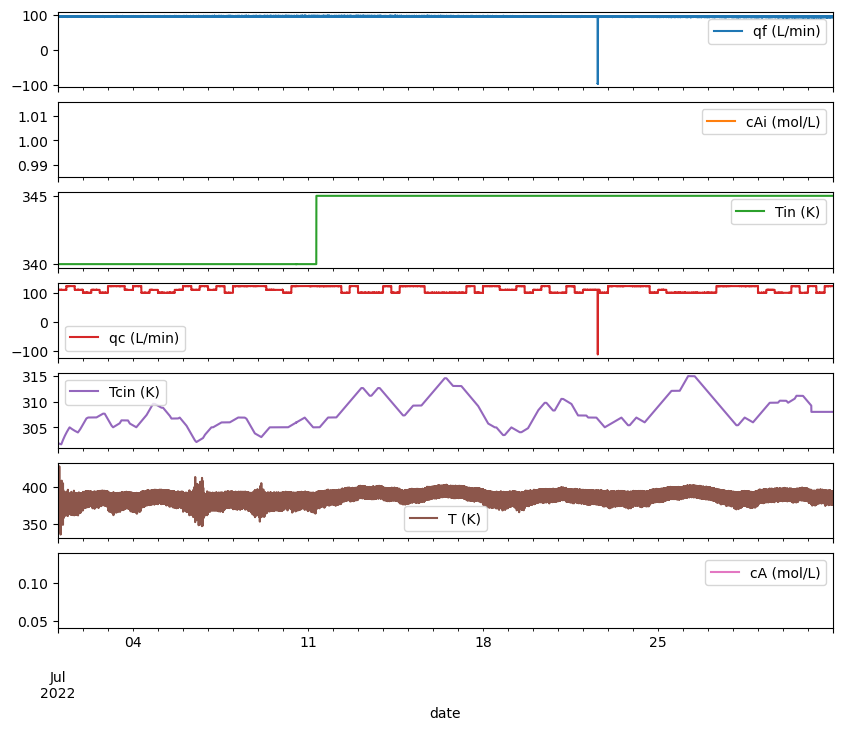

In [1488]:
df.plot(subplots=True, figsize=(10,8))

Identify any concerns / issues with the data, and briefly discuss these.

...



### 2.b Clean the data

In [1489]:
#Count missing values in all variables in data frame
print("Missing data fractions:")
for colname in list(df.columns):
    missingpercent = 100*df[colname].isnull().sum()/len(df)
    print(f"{missingpercent:.1f} % missing in {colname}")

Missing data fractions:
0.1 % missing in qf (L/min)
99.2 % missing in cAi (mol/L)
0.1 % missing in Tin (K)
0.1 % missing in qc (L/min)
0.1 % missing in Tcin (K)
0.1 % missing in T (K)
99.2 % missing in cA (mol/L)


In [1490]:
df3 = df.copy(deep=True)

In [1491]:
df3.dropna(inplace=True)

In [1492]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 347 entries, 2022-07-01 02:19:00 to 2022-07-31 23:59:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   qf (L/min)   347 non-null    float64
 1   cAi (mol/L)  347 non-null    float64
 2   Tin (K)      347 non-null    float64
 3   qc (L/min)   347 non-null    float64
 4   Tcin (K)     347 non-null    float64
 5   T (K)        347 non-null    float64
 6   cA (mol/L)   347 non-null    float64
dtypes: float64(7)
memory usage: 21.7 KB


In [1493]:
colname = ['qf (L/min)', 'cAi (mol/L)', 'T (K)', 'cA (mol/L)']
for col in colname:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df3.loc[(df3[col] < lower_bound) | (df3[col] > upper_bound)]= np.nan

<Axes: >

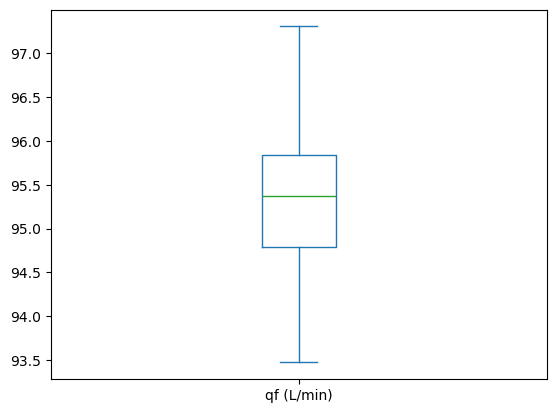

In [1494]:
df3['qf (L/min)'].plot.box()

<Axes: >

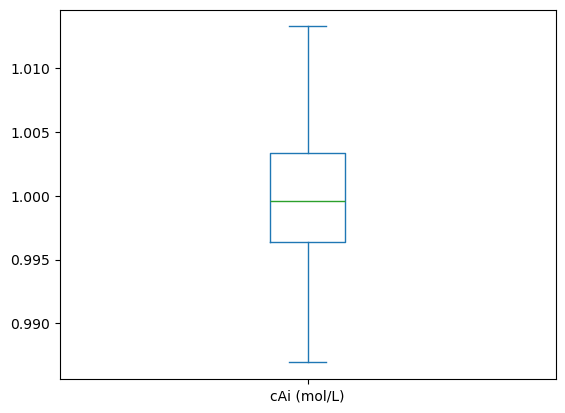

In [1495]:
df3["cAi (mol/L)"].plot.box()

<Axes: >

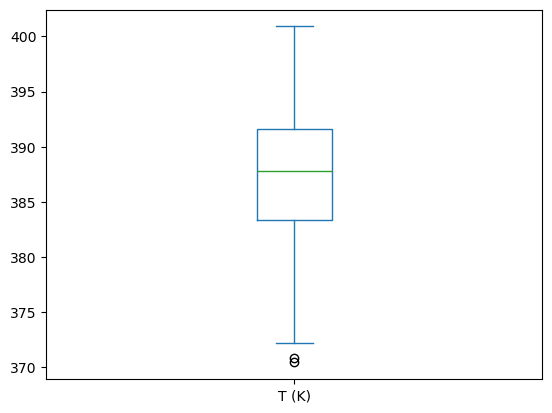

In [1496]:
df3["T (K)"].plot.box()

<Axes: >

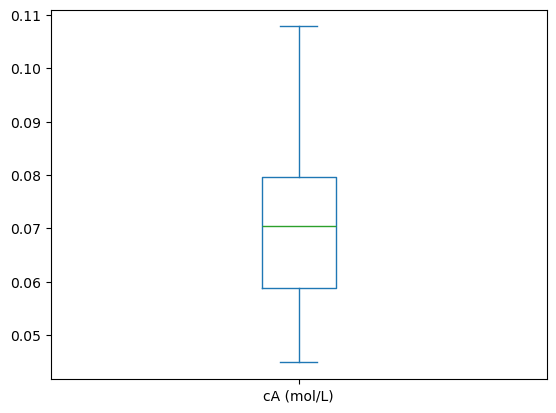

In [1497]:
df3["cA (mol/L)"].plot.box()

In [1498]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 347 entries, 2022-07-01 02:19:00 to 2022-07-31 23:59:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   qf (L/min)   334 non-null    float64
 1   cAi (mol/L)  334 non-null    float64
 2   Tin (K)      334 non-null    float64
 3   qc (L/min)   334 non-null    float64
 4   Tcin (K)     334 non-null    float64
 5   T (K)        334 non-null    float64
 6   cA (mol/L)   334 non-null    float64
dtypes: float64(7)
memory usage: 21.7 KB


In [1499]:
print("Missing data:")
for colname in list(df3.columns):
    missingpercent = df3[colname].isnull().sum()
    print(f"{missingpercent:.3f}  missing in {colname}")

Missing data:
13.000  missing in qf (L/min)
13.000  missing in cAi (mol/L)
13.000  missing in Tin (K)
13.000  missing in qc (L/min)
13.000  missing in Tcin (K)
13.000  missing in T (K)
13.000  missing in cA (mol/L)


In [1500]:
df3.head()

,qf (L/min),cAi (mol/L),Tin (K),qc (L/min),Tcin (K),T (K),cA (mol/L)
date,,,,,,,
2022-07-01 02:19:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-07-01 04:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-07-01 06:41:00,94.165359,0.996601,340.0,110.063348,303.377724,385.662892,0.105688
2022-07-01 09:01:00,95.838058,1.000698,340.0,122.939638,304.285714,388.187337,0.096822
2022-07-01 10:42:00,95.864535,1.004122,340.0,122.937563,304.857369,389.617806,0.096038


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

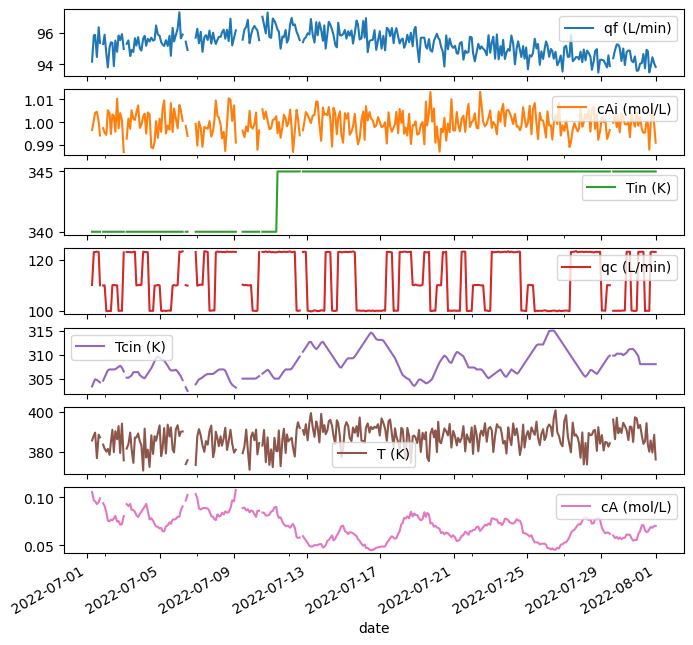

In [1501]:
df3.plot(subplots=True, figsize=(8,8))

In [1502]:
#Count missing values in all variables in data frame
print("Missing data:")
for colname in list(df3.columns):
    missingpercent = df3[colname].isnull().sum()
    print(f"{missingpercent:.3f}  missing in {colname}")

Missing data:
13.000  missing in qf (L/min)
13.000  missing in cAi (mol/L)
13.000  missing in Tin (K)
13.000  missing in qc (L/min)
13.000  missing in Tcin (K)
13.000  missing in T (K)
13.000  missing in cA (mol/L)


In [1503]:
df3['qf (L/min)'] = df3['qf (L/min)'].interpolate(method='time').bfill()
df3['cAi (mol/L)'] = df3['cAi (mol/L)'].interpolate(method='time').bfill()
df3['Tin (K)'] = df3['Tin (K)'].interpolate(method='time').bfill()
df3['qc (L/min)'] = df3['qc (L/min)'].interpolate(method='time').bfill()
df3['Tcin (K)'] = df3['Tcin (K)'].interpolate(method='time').bfill()
df3['T (K)'] = df3['T (K)'].interpolate(method='time').bfill()
df3['cA (mol/L)'] = df3['cA (mol/L)'].interpolate(method='time').bfill()

In [1504]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 347 entries, 2022-07-01 02:19:00 to 2022-07-31 23:59:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   qf (L/min)   347 non-null    float64
 1   cAi (mol/L)  347 non-null    float64
 2   Tin (K)      347 non-null    float64
 3   qc (L/min)   347 non-null    float64
 4   Tcin (K)     347 non-null    float64
 5   T (K)        347 non-null    float64
 6   cA (mol/L)   347 non-null    float64
dtypes: float64(7)
memory usage: 21.7 KB


In [1505]:
df3.head()

,qf (L/min),cAi (mol/L),Tin (K),qc (L/min),Tcin (K),T (K),cA (mol/L)
date,,,,,,,
2022-07-01 02:19:00,94.165359,0.996601,340.0,110.063348,303.377724,385.662892,0.105688
2022-07-01 04:21:00,94.165359,0.996601,340.0,110.063348,303.377724,385.662892,0.105688
2022-07-01 06:41:00,94.165359,0.996601,340.0,110.063348,303.377724,385.662892,0.105688
2022-07-01 09:01:00,95.838058,1.000698,340.0,122.939638,304.285714,388.187337,0.096822
2022-07-01 10:42:00,95.864535,1.004122,340.0,122.937563,304.857369,389.617806,0.096038


In [1506]:
df4 = df3.copy(deep=True)

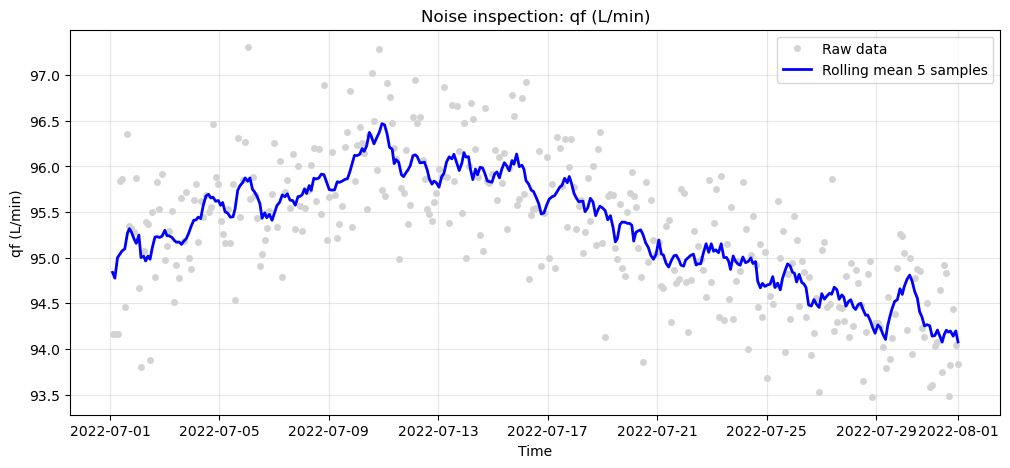

In [1507]:
plt.figure(figsize=(12,5))
plt.plot(df3.index, df3["qf (L/min)"], 'o', color='lightgray', markersize=4, label='Raw data')
plt.plot(df4['qf (L/min)'].rolling(window=10,center=True , min_periods=1).mean(), color='blue', linewidth=2,
         label='Rolling mean 5 samples')
plt.title("Noise inspection: qf (L/min)")
plt.xlabel("Time")
plt.ylabel("qf (L/min)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


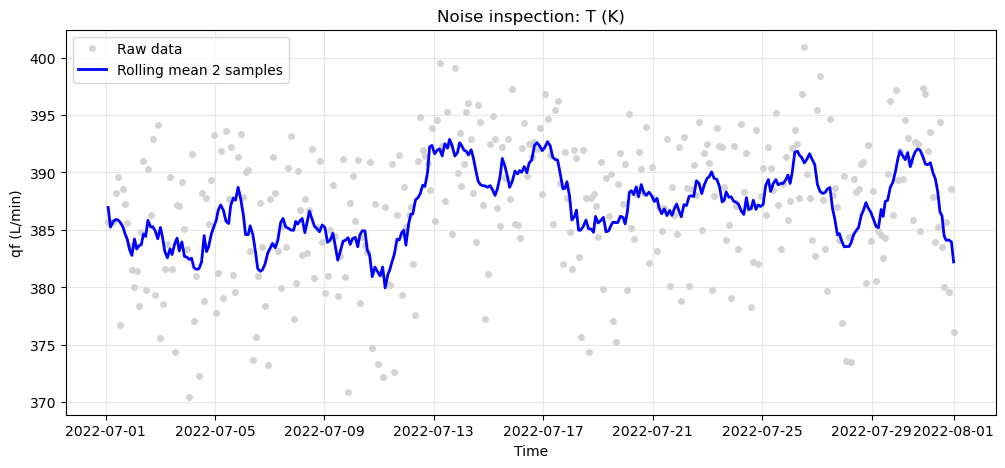

In [1508]:
plt.figure(figsize=(12,5))
plt.plot(df3.index, df3["T (K)"], 'o', color='lightgray', markersize=4, label='Raw data')
plt.plot(df4["T (K)"].rolling(window=10
,center=True , min_periods=1).mean(), color='blue', linewidth=2,
         label='Rolling mean 2 samples')
plt.title("Noise inspection: T (K)")
plt.xlabel("Time")
plt.ylabel("qf (L/min)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

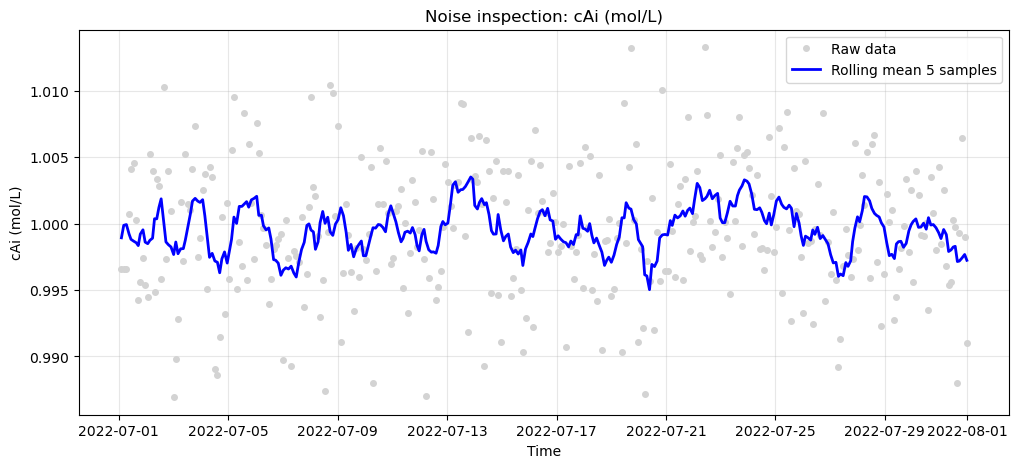

In [1509]:
plt.figure(figsize=(12,5))
plt.plot(df3.index, df3["cAi (mol/L)"], 'o', color='lightgray', markersize=4, label='Raw data')
plt.plot(df4["cAi (mol/L)"].rolling(window=10,center=True , min_periods=1).mean(), color='blue', linewidth=2,
         label='Rolling mean 5 samples')
plt.title("Noise inspection: cAi (mol/L)")
plt.xlabel("Time")
plt.ylabel("cAi (mol/L)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

don't forget to mention why you used mean and not median 

In [1510]:
df3['qf (L/min)'] = df3['qf (L/min)'].rolling(window=10 , center=True , min_periods=1).mean()
df3['T (k)'] = df3['qf (L/min)'].rolling(window=10 , center=True , min_periods=1).mean()
df3['cAi (mol/L)'] = df3['cAi (mol/L)'].rolling(window=10 , center=True , min_periods=1).mean()

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

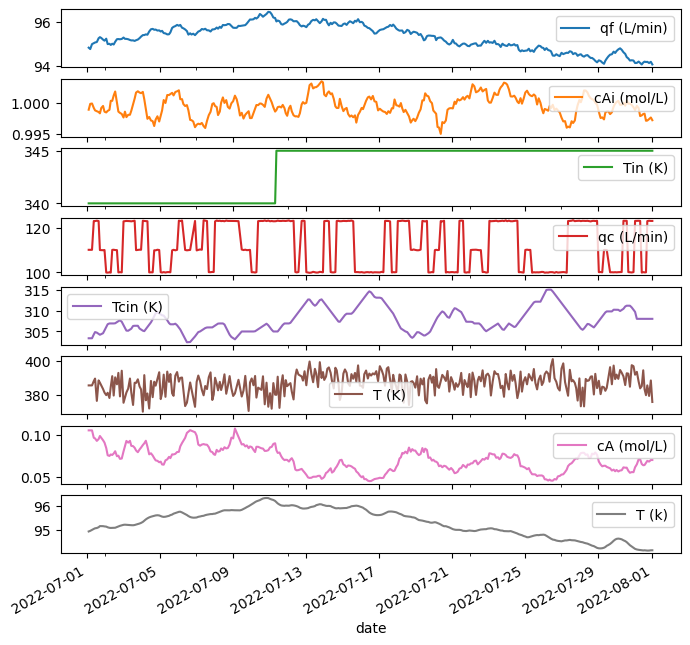

In [1511]:
df3.plot(subplots=True, figsize=(8,8))

## TASK 3: Model Development and Evaluation
### 3.a Transform and partition your data appropriately

In [1512]:
# Input keys are only your disturbance & manipulated data, NO STATE VARIABLES T(K)
input_keys = ['qf (L/min)', 'qc (L/min)', 'cAi (mol/L)', 'Tin (K)', 'Tcin (K)', 'T (K)']
X = df3[input_keys]
Y = df3['cA (mol/L)'].values.reshape(-1, 1)

In [1513]:
# Split fractions
test_fraction = 0.2
valid_fraction = 0.3
valid_tv_fraction = valid_fraction / (1 - test_fraction)

# Split data set: Test and train/validation
x_trainvalid, x_test, y_trainvalid, y_test = train_test_split(X, Y, test_size=test_fraction, shuffle=False)

# Split data set: Train and validation
x_train, x_valid, y_train, y_valid = train_test_split(x_trainvalid, y_trainvalid, test_size=valid_tv_fraction, shuffle=False)

# Size of data sets
print('Size of training data: %0.0f' % len(y_train))
print('Size of validation data: %0.0f' % len(y_valid))
print('Size of testing data: %0.0f' % len(y_test))

Size of training data: 173
Size of validation data: 104
Size of testing data: 70


In [1514]:
# Standardize and scale data
sx = StandardScaler()
xs_train = sx.fit_transform(x_train)
xs_valid = sx.transform(x_valid)
xs_test = sx.transform(x_test)

sy = StandardScaler()
ys_train = sy.fit_transform(y_train)
ys_valid = sy.transform(y_valid)
ys_test = sy.transform(y_test)

In [1515]:
X_scaled = sx.transform(X)
Y_scaled = sy.transform(Y)

### 3.b Train a linear regression, KNN, and neural network model

...



In [1516]:
# Train linear regression model
lm = LinearRegression()
lm.fit(xs_train,ys_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1517]:
# Train K-nearest neighbor model

# Model A: 5 neighbors
knn_A = KNeighborsRegressor(n_neighbors=5)
knn_A.fit(xs_train, ys_train)

# Model B: 8 neighbors
knn_B = KNeighborsRegressor(n_neighbors=8)
knn_B.fit(xs_train, ys_train)

# Model C: 10 neighbors
knn_C = KNeighborsRegressor(n_neighbors=10)
knn_C.fit(xs_train, ys_train)



,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [1518]:
# Train neural network
node_function = 'relu'
max_iter = 1000

# Model A: [5]
layer_spec_A = [5]
nnA = MLPRegressor(hidden_layer_sizes=layer_spec_A, activation=node_function, max_iter=max_iter)
nnA.fit(xs_train, ys_train.ravel())

# Model B: [5, 5]
layer_spec_B = [5, 5]
nnB = MLPRegressor(hidden_layer_sizes=layer_spec_B, activation=node_function, max_iter=max_iter)
nnB.fit(xs_train, ys_train.ravel())

# Model C: [5, 5, 5]
layer_spec_C = [5, 5, 5] 
nnC = MLPRegressor(hidden_layer_sizes=layer_spec_C, activation=node_function, max_iter=max_iter)
nnC.fit(xs_train, ys_train.ravel())


,loss,'squared_error'
,hidden_layer_sizes,"[5, 5, ...]"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


### 3.c Choose and justify your model to advance based on its performance on predicting the validation data.

In [1519]:
# Linear Regression : Predict KPI using validation data 
Ypredlm = lm.predict(xs_valid)

# R-squared
lmR2 = r2_score(ys_valid, Ypredlm)
print('R² (Validation) - Linear Regression Model: %.3f' % lmR2)

# Mean Squared Error
lmMSE = mean_squared_error(ys_valid, Ypredlm)
print('MSE (Validation) - Linear Regression Model: %.3f' % lmMSE)


R² (Validation) - Linear Regression Model: 0.742
MSE (Validation) - Linear Regression Model: 0.114


In [1520]:

# Model A (5 neighbors)
Ypred_knnA = knn_A.predict(xs_valid)
knnA_R2 = r2_score(ys_valid, Ypred_knnA)
knnA_MSE = mean_squared_error(ys_valid, Ypred_knnA)
print(f'Model A (5 neighbors): R² = {knnA_R2:.3f}, MSE = {knnA_MSE:.3f}')

# Model B (8 neighbors)
Ypred_knnB = knn_B.predict(xs_valid)
knnB_R2 = r2_score(ys_valid, Ypred_knnB)
knnB_MSE = mean_squared_error(ys_valid, Ypred_knnB)
print(f'Model B (8 neighbors): R² = {knnB_R2:.3f}, MSE = {knnB_MSE:.3f}')

# Model C (10 neighbors)
Ypred_knnC = knn_C.predict(xs_valid)
knnC_R2 = r2_score(ys_valid, Ypred_knnC)
knnC_MSE = mean_squared_error(ys_valid, Ypred_knnC)
print(f'Model C (10 neighbors): R² = {knnC_R2:.3f}, MSE = {knnC_MSE:.3f}')



Model A (5 neighbors): R² = 0.255, MSE = 0.329
Model B (8 neighbors): R² = 0.294, MSE = 0.311
Model C (10 neighbors): R² = 0.346, MSE = 0.288


In [1521]:
# Neural Network Model A ([6])
YprednnA_valid = nnA.predict(xs_valid)
nnR2_A = r2_score(ys_valid, YprednnA_valid)
print('R² (Validation) - Neural Network Model A [5]: %.3f' % nnR2_A)

mse_valid_A = mean_squared_error(ys_valid, YprednnA_valid)
print('MSE (Validation) - Neural Network Model A [5]: %.3f' % mse_valid_A)

# Neural Network Model B ([6,6])
YprednnB_valid = nnB.predict(xs_valid)
nnR2_B = r2_score(ys_valid, YprednnB_valid)
print('R² (Validation) - Neural Network Model B [5,5]: %.3f' % nnR2_B)

mse_valid_B = mean_squared_error(ys_valid, YprednnB_valid)
print('MSE (Validation) - Neural Network Model B [5,5]: %.3f' % mse_valid_B)

# Neural Network Model C ([6,6,6])
YprednnC_valid = nnC.predict(xs_valid)
nnR2_C = r2_score(ys_valid, YprednnC_valid)
print('R² (Validation) - Neural Network Model C [5,5,5]: %.3f' % nnR2_C)

mse_valid_C = mean_squared_error(ys_valid, YprednnC_valid)
print('MSE (Validation) - Neural Network Model C [5,5,5]: %.3f' % mse_valid_C)


R² (Validation) - Neural Network Model A [5]: 0.250
MSE (Validation) - Neural Network Model A [5]: 0.331
R² (Validation) - Neural Network Model B [5,5]: 0.611
MSE (Validation) - Neural Network Model B [5,5]: 0.172
R² (Validation) - Neural Network Model C [5,5,5]: 0.199
MSE (Validation) - Neural Network Model C [5,5,5]: 0.353


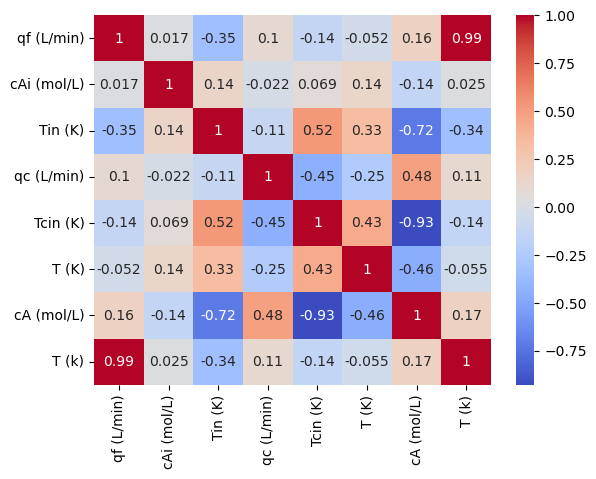

In [1522]:
corr = df3.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

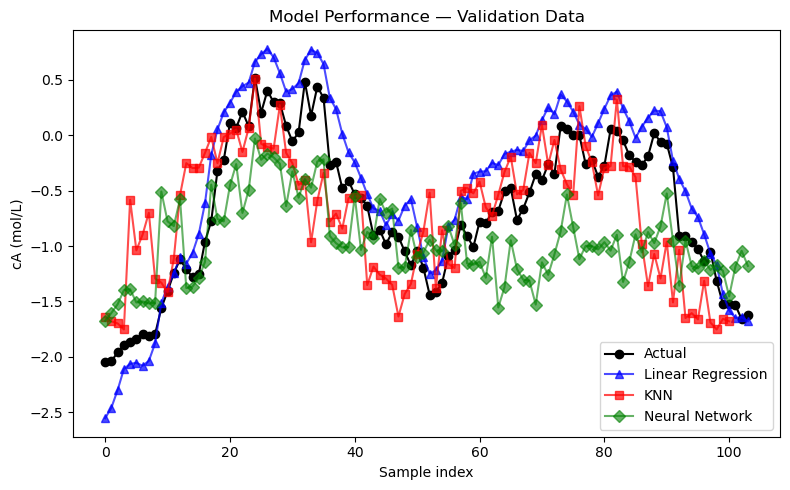

In [1523]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ys_valid, 'ko-', label='Actual')
ax.plot(Ypredlm, 'b^-', alpha=0.7, label='Linear Regression')
ax.plot(Ypredknn, 'rs-', alpha=0.7, label='KNN')
ax.plot(YprednnA_valid, 'gD-', alpha=0.6, label='Neural Network')
ax.set_xlabel('Sample index')
ax.set_ylabel('cA (mol/L)')
ax.set_title('Model Performance — Validation Data')
ax.legend()
plt.tight_layout()
plt.show()


### 3.d Evaluate the advanced model on the test data, identify key input variables. Comment on both the perfomance and whether the identified variables align to your domain knowledge

The best model is Linear Regression, it has the highest R^2 and lowest MSE 

In [1524]:
# Linear Regression : Predict KPI using testing data 
Ypredlm_F = lm.predict(xs_test)

# R-squared
lmR2 = r2_score(ys_test, Ypredlm_F)
print('R² (Validation) - Linear Regression Model: %.3f' % lmR2)

# Mean Squared Error
lmMSE = mean_squared_error(ys_test, Ypredlm_F)
print('MSE (Validation) - Linear Regression Model: %.3f' % lmMSE)

R² (Validation) - Linear Regression Model: 0.731
MSE (Validation) - Linear Regression Model: 0.103


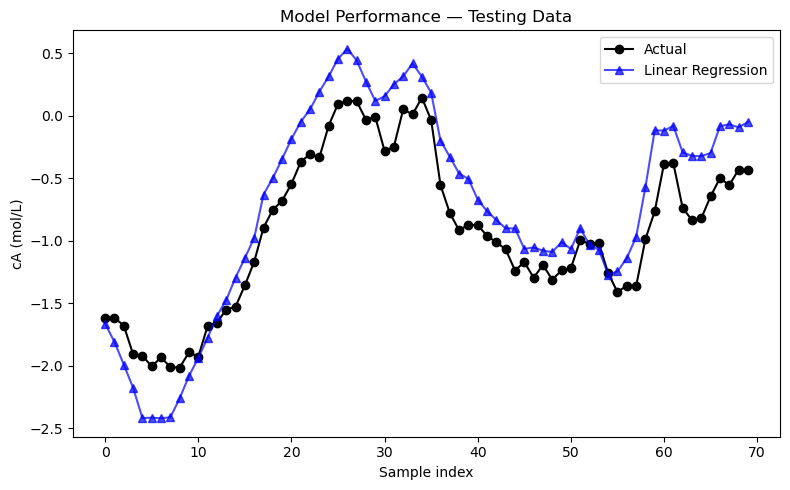

In [1525]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ys_test, 'ko-', label='Actual')
ax.plot(Ypredlm_F, 'b^-', alpha=0.7, label='Linear Regression')
ax.set_xlabel('Sample index')
ax.set_ylabel('cA (mol/L)')
ax.set_title('Model Performance — Testing Data')
ax.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Mean accuracy decrease')

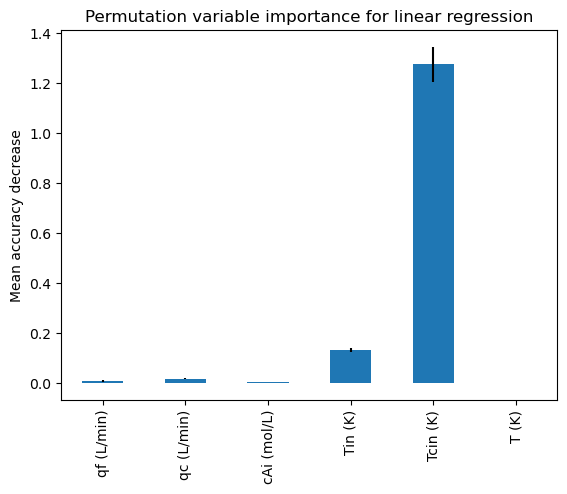

In [1526]:
# Inspect variable importance: Linear regression
lmVIresult = permutation_importance(lm,X_scaled,Y_scaled,n_repeats=10)
lmVImean = pd.Series(lmVIresult.importances_mean,index=df3[input_keys].columns)
fig, ax = plt.subplots()
lmVImean.plot.bar(yerr=lmVIresult.importances_std,ax=ax)
ax.set_title('Permutation variable importance for linear regression')
ax.set_ylabel('Mean accuracy decrease')

This makes sense because the model checks how much the accuracy drops when each variable is randomly shuffled. Since there were minimial changes in qf, qc,cAi with Tin(K) kept nearly constant, shuffling did not effect the predicted KPI. However Tcin(K) showed much greater variation, so shuffling it distrupted the model's prediction and caused the acuracy to drop.

Now lets do a Partial dependence, reason : PFI tells you which variables are important while Partial dependence show you how those vairables affect the prediciton whether it's increasing or decreasing or not.

Text(0.5, 0.98, 'Neural networks: Partial Dependence')

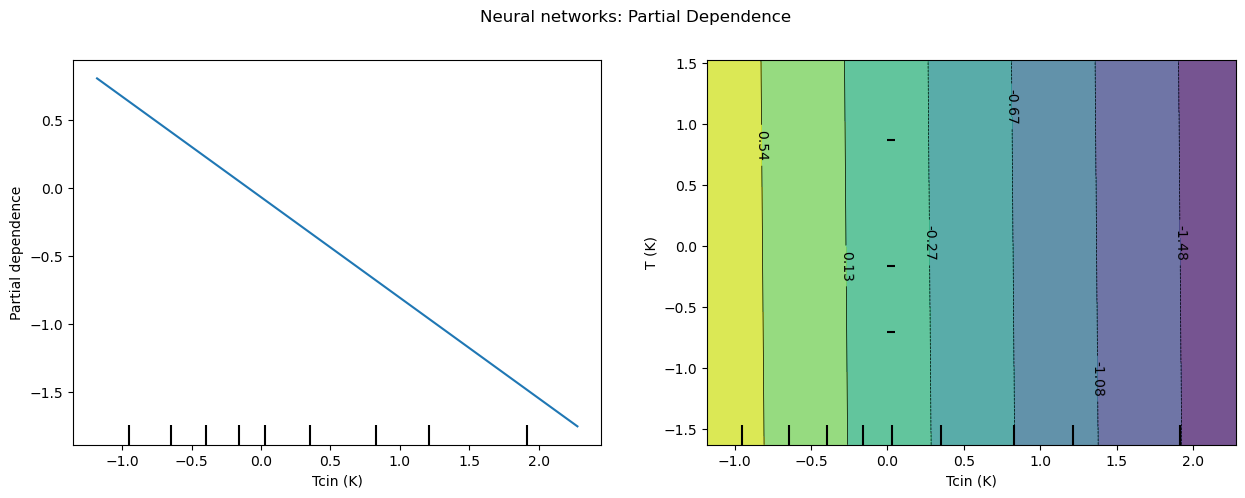

In [1531]:
# Model interpretation: Partial dependence for neural network
# Note: partial dependence has 0 as mean of predictor
fig, ax = plt.subplots(figsize=(15,5))
x1 = 'Tcin (K)'
x2 = 'T (K)'
PartialDependenceDisplay.from_estimator(lm,X_scaled,[x1,[x1,x2]],feature_names=input_keys,ax=ax)
fig.suptitle('Neural networks: Partial Dependence')

The partial dependency plot shows a negative linear relationship between Tcin(K) and the predicted effluent concentrations(cA). As coolant temperture increases, the model predicts a decrease in cA, meaning higher coolant tempertures reduce cooling efficiency, raise the reactor temperture, and increase reaction rate - leasing to lower remaining A in the outlet stream.

## Task 4: Predictive analytics
Predict the effluent concentration of A for coolant flowrates of 50 to 150 L/min if the coolant flowrate is supplied at 298 K going forward. 

In [1532]:
qc_range = np.arange(50, 151, 10)   # from 50 to 150 L/min in steps of 10
Tcin_ref = 298                      # K

coolant_df = pd.DataFrame({
    'qf (L/min)': df['qf (L/min)'].mean(),
    'cAi (mol/L)': df['cAi (mol/L)'].mean(),
    'Tin (K)': df['Tin (K)'].mean(),
    'qc (L/min)': qc_range,
    'Tcin (K)': Tcin_ref,
    'T (K)': df['T (K)'].mean()
})

coolant_df = coolant_df[input_keys]


X_scaled = sx.transform(coolant_df)


y_scaled_pred = lm.predict(X_scaled)


y_pred = sy.inverse_transform(y_scaled_pred.reshape(-1, 1))


coolant_df['Predicted_cA (mol/L)'] = y_pred

coolant_df



,qf (L/min),qc (L/min),cAi (mol/L),Tin (K),Tcin (K),T (K),Predicted_cA (mol/L)
0,95.210836,50,0.999572,343.335238,298,386.314923,0.106884
1,95.210836,60,0.999572,343.335238,298,386.314923,0.108398
2,95.210836,70,0.999572,343.335238,298,386.314923,0.109912
3,95.210836,80,0.999572,343.335238,298,386.314923,0.111426
4,95.210836,90,0.999572,343.335238,298,386.314923,0.112941
5,95.210836,100,0.999572,343.335238,298,386.314923,0.114455
6,95.210836,110,0.999572,343.335238,298,386.314923,0.115969
7,95.210836,120,0.999572,343.335238,298,386.314923,0.117483
8,95.210836,130,0.999572,343.335238,298,386.314923,0.118997
9,95.210836,140,0.999572,343.335238,298,386.314923,0.120511


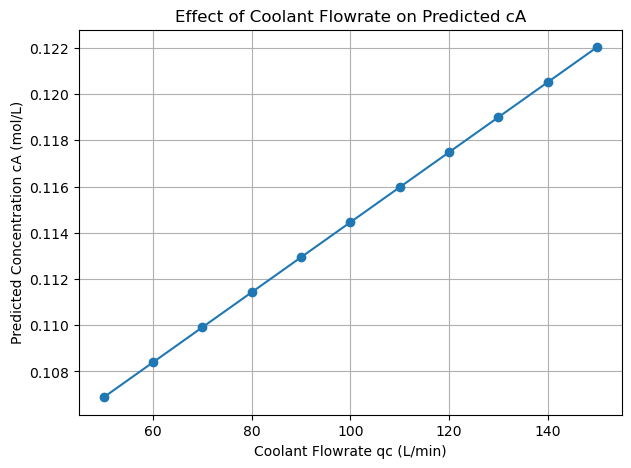

In [1533]:
# --- Plot predicted cA vs coolant flowrate ---
plt.figure(figsize=(7,5))
plt.plot(coolant_df['qc (L/min)'], coolant_df['Predicted_cA (mol/L)'], marker='o', linestyle='-')
plt.xlabel('Coolant Flowrate qc (L/min)')
plt.ylabel('Predicted Concentration cA (mol/L)')
plt.title('Effect of Coolant Flowrate on Predicted cA')
plt.grid(True)
plt.show()